# Notebook 04 — Baseline Model

## Ziel
Einfaches CNN von Grund auf trainieren — ohne Transfer Learning.
Dient als Referenzpunkt: wie gut ist ein einfaches Modell?
Transfer Learning (Notebook 05) muss diesen Wert übertreffen.

## Warum Baseline?
Ohne Baseline kein Vergleich.
"70% Accuracy" ist gut oder schlecht — relativ zu was?

| Modell | Erwartete Accuracy |
|--------|-------------------|
| Random Guess | ~10% |
| **Baseline CNN (dieses Notebook)** | **~45–60%** |
| ResNet50 Transfer Learning | ~70–78% |
| State-of-the-Art | ~99.5% |

## Inhalt

| Zelle | Inhalt |
|-------|--------|
| 01 | Setup & Imports + Pipeline laden |
| 02 | Baseline CNN Architektur |
| 03 | Modell kompilieren |
| 04 | Training mit ModelCheckpoint |
| 05 | Training visualisieren (Loss/Accuracy Kurven) |
| 06 | Erste Evaluation |
| 07 | Fehleranalyse — wo versagt das Modell? |
| 08 | Fazit & Vergleich mit Erwartung |

In [1]:
# =============================================================================
# Zelle 01 – Setup & Imports + Pipeline laden
# =============================================================================
# Notebook 04 baut auf Notebook 03 auf.
# Pipeline wird hier neu erstellt — Colab hat keinen persistenten State.
# Alle Preprocessing-Entscheidungen aus Notebook 03 werden übernommen.
# =============================================================================

# ── Google Drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Konfiguration ──────────────────────────────────────────────────────────────
CONFIG = {
    'base_path'    : '/content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10',
    'repo_path'    : '/content/MIST_CV_CIFAR10',
    'github_user'  : 'AwaTekoete',
    'github_email' : 'erik.gerst@hotmail.com',
    'seed'         : 42,
    'n_train'      : 10000,
    'batch_size'   : 32,
    'n_classes'    : 10,
    'img_size'     : 32,
}

# ── Imports ───────────────────────────────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ── Reproduzierbarkeit ────────────────────────────────────────────────────────
SEED = CONFIG['seed']
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use('dark_background')

CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# ── Datensatz laden ───────────────────────────────────────────────────────────
(train_images_raw, train_labels_raw), (test_images, test_labels) = cifar10.load_data()
train_labels_raw = train_labels_raw.flatten()
test_labels      = test_labels.flatten()

# Shuffle + Limitierung (identisch Notebook 03)
np.random.seed(SEED)
shuffle_idx    = np.random.permutation(len(train_images_raw))
train_images_s = train_images_raw[shuffle_idx]
train_labels_s = train_labels_raw[shuffle_idx]

n              = CONFIG['n_train']
train_images   = train_images_s[:n]
train_labels   = train_labels_s[:n]

# ── Validation Split ──────────────────────────────────────────────────────────
VAL_RATIO        = 0.2
VAL_SIZE         = int(len(train_images) * VAL_RATIO)
TRAIN_SIZE_FINAL = len(train_images) - VAL_SIZE

np.random.seed(SEED)
indices  = np.random.permutation(len(train_images))
val_idx  = indices[:VAL_SIZE]
train_idx = indices[VAL_SIZE:]

X_train = train_images[train_idx]
y_train = train_labels[train_idx]
X_val   = train_images[val_idx]
y_val   = train_labels[val_idx]

# ── Augmentation ──────────────────────────────────────────────────────────────
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal', seed=SEED),
    tf.keras.layers.RandomTranslation(0.1, 0.1, fill_mode='reflect', seed=SEED),
    tf.keras.layers.RandomBrightness(0.2, seed=SEED),
    tf.keras.layers.RandomContrast(0.2, seed=SEED),
], name='data_augmentation')

# ── Pipeline Funktionen ───────────────────────────────────────────────────────
def prepare_train(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, axis=0)
    image = data_augmentation(image, training=True)
    image = tf.squeeze(image, axis=0)
    image = preprocess_input(image)
    return image, label

def prepare_val_test(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

# ── tf.data Pipelines ────────────────────────────────────────────────────────
BATCH_SIZE = CONFIG['batch_size']
AUTOTUNE   = tf.data.AUTOTUNE

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .cache()
    .shuffle(TRAIN_SIZE_FINAL, seed=SEED, reshuffle_each_iteration=True)
    .map(prepare_train, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .cache()
    .map(prepare_val_test, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    .map(prepare_val_test, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Verifikation ──────────────────────────────────────────────────────────────
print("=" * 55)
print("SETUP — Notebook 04 Baseline")
print("=" * 55)
print(f"\nTensorFlow  : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU         : {'✅ verfügbar' if gpus else '❌ NICHT verfügbar'}")
print(f"\nSplit:")
print(f"  Training   : {len(X_train):,}")
print(f"  Validation : {len(X_val):,}")
print(f"  Test       : {len(test_images):,}")
print(f"\nPipeline:")
print(f"  Train Batches : {len(train_dataset)}")
print(f"  Val Batches   : {len(val_dataset)}")
print(f"  Test Batches  : {len(test_dataset)}")
print(f"\n✓ Setup abgeschlossen — Bereit für Modellbau")
print("=" * 55)

Mounted at /content/drive
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
SETUP — Notebook 04 Baseline

TensorFlow  : 2.20.0
GPU         : ❌ NICHT verfügbar

Split:
  Training   : 8,000
  Validation : 2,000
  Test       : 10,000

Pipeline:
  Train Batches : 250
  Val Batches   : 63
  Test Batches  : 313

✓ Setup abgeschlossen — Bereit für Modellbau


### Zelle 01 — Setup & Imports + Pipeline

#### Was
Identisch mit Notebook 03 — Pipeline wird neu erstellt.
Notebooks sind self-contained — kein persistenter State zwischen Sessions.

#### Kaggle vs. Colab
Dieses Notebook läuft in Colab.
Bei GPU-Limit: Kaggle als Alternative (30h/Woche kostenlos).
Pipeline-Code ist in beiden Umgebungen identisch — nur Pfade unterscheiden sich.

#### Ergebnis
```
TensorFlow  : 2.20.0
GPU         : wird für Training benötigt
Train       : 8.000 Samples
Validation  : 2.000 Samples
Test        : 10.000 Samples
```

In [2]:
# =============================================================================
# Zelle 02 – Baseline CNN Architektur
# =============================================================================
# Einfaches CNN von Grund auf — kein Transfer Learning.
# Zweck: Referenzpunkt für Transfer Learning (Notebook 05).
# Architektur: 3 Convolutional Blocks + Dense Head
#
# Designprinzipien:
# - Klein genug für schnelles Training
# - Groß genug um sinnvolle Features zu lernen
# - BatchNormalization für Trainingsstabilität
# - Dropout gegen Overfitting
# =============================================================================

def build_baseline_cnn(input_shape=(32, 32, 3), n_classes=10):
    """
    Baseline CNN für CIFAR-10.

    Architektur:
    Input → Conv Block 1 → Conv Block 2 → Conv Block 3 → Dense Head → Output

    Jeder Conv Block:
    Conv2D → BatchNorm → ReLU → Conv2D → BatchNorm → ReLU → MaxPool → Dropout
    """
    inputs = layers.Input(shape=input_shape, name='input')

    # ── Conv Block 1 — niedrige Features (Kanten, Texturen) ──────────────────
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1_1')(inputs)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.Activation('relu', name='relu1_1')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.Activation('relu', name='relu1_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)
    x = layers.Dropout(0.25, name='drop1')(x)
    # Shape: (16, 16, 32)

    # ── Conv Block 2 — mittlere Features (Formen, Muster) ────────────────────
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.Activation('relu', name='relu2_1')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.Activation('relu', name='relu2_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)
    x = layers.Dropout(0.25, name='drop2')(x)
    # Shape: (8, 8, 64)

    # ── Conv Block 3 — hohe Features (Objekte, Klassen) ──────────────────────
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3_1')(x)
    x = layers.BatchNormalization(name='bn3_1')(x)
    x = layers.Activation('relu', name='relu3_1')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3_2')(x)
    x = layers.BatchNormalization(name='bn3_2')(x)
    x = layers.Activation('relu', name='relu3_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)
    x = layers.Dropout(0.25, name='drop3')(x)
    # Shape: (4, 4, 128)

    # ── Dense Head — Klassifikation ───────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)  # (4,4,128) → (128,)
    x = layers.Dense(256, name='dense1')(x)
    x = layers.BatchNormalization(name='bn_dense')(x)
    x = layers.Activation('relu', name='relu_dense')(x)
    x = layers.Dropout(0.5, name='drop_dense')(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='baseline_cnn')
    return model

# ── Modell erstellen ──────────────────────────────────────────────────────────
baseline_model = build_baseline_cnn(
    input_shape=(CONFIG['img_size'], CONFIG['img_size'], 3),
    n_classes=CONFIG['n_classes']
)

# ── Modell zusammenfassen ─────────────────────────────────────────────────────
print("=" * 55)
print("BASELINE CNN — Architektur")
print("=" * 55)
baseline_model.summary()

# ── Parameter zählen ─────────────────────────────────────────────────────────
total_params    = baseline_model.count_params()
trainable       = sum([tf.size(w).numpy() for w in baseline_model.trainable_weights])
non_trainable   = sum([tf.size(w).numpy() for w in baseline_model.non_trainable_weights])

print(f"\nParameter-Übersicht:")
print(f"  Total         : {total_params:,}")
print(f"  Trainierbar   : {trainable:,}")
print(f"  Nicht-train.  : {non_trainable:,}")
print(f"\nVergleich ResNet50: ~25,600,000 Parameter")
print(f"Baseline CNN      : {total_params:,} Parameter")
print(f"Faktor            : {25600000/total_params:.1f}× kleiner als ResNet50")

BASELINE CNN — Architektur


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (Activation)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (Activation)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (Activation)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (Activation)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (Activation)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_2 (Activation)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 4, 4, 128)      │             

 Total params: 325,418 (1.24 MB)

 Trainable params: 324,010 (1.24 MB)

 Non-trainable params: 1,408 (5.50 KB)


Parameter-Übersicht:
  Total         : 325,418
  Trainierbar   : 324,010
  Nicht-train.  : 1,408

Vergleich ResNet50: ~25,600,000 Parameter
Baseline CNN      : 325,418 Parameter
Faktor            : 78.7× kleiner als ResNet50


### Zelle 02 — Baseline CNN Architektur

#### Was
Einfaches CNN mit 3 Convolutional Blocks — von Grund auf trainiert.
325,418 Parameter — 78.7× kleiner als ResNet50.

#### Architektur-Übersicht
Input (32,32,3)
↓
Conv Block 1: Conv→BN→ReLU→Conv→BN→ReLU→MaxPool→Dropout(0.25)
(32,32,3) → (16,16,32)
↓
Conv Block 2: Conv→BN→ReLU→Conv→BN→ReLU→MaxPool→Dropout(0.25)
(16,16,32) → (8,8,64)
↓
Conv Block 3: Conv→BN→ReLU→Conv→BN→ReLU→MaxPool→Dropout(0.25)
(8,8,64) → (4,4,128)
↓
GlobalAveragePooling2D → (128,)
↓
Dense(256) → BN → ReLU → Dropout(0.5)
↓
Dense(10) → Softmax

#### Konzept: Warum Conv Blocks verdoppeln (32→64→128)?
Tiefere Schichten lernen abstraktere Features:
- Block 1 (32 Filter): Kanten, Farben, einfache Texturen
- Block 2 (64 Filter): Formen, Muster, Kombinationen
- Block 3 (128 Filter): Objektteile, komplexe Strukturen

Mehr Filter = mehr lernbare Features = mehr Kapazität.
Aber: mehr Filter = mehr Parameter = Overfitting-Risiko.
→ Dropout nach jedem Block als Gegenmaßnahme.

#### Konzept: BatchNormalization
Ohne BN: Aktivierungen driften → Training instabil
Mit BN:  Aktivierungen normalisiert → stabiles Training
BN normalisiert den Output jeder Schicht auf Mean≈0, Std≈1.
Non-trainable Parameter (1,408): Moving Mean und Variance —
werden während Training berechnet, nicht per Backpropagation optimiert.

#### Konzept: GlobalAveragePooling2D vs. Flatten
Flatten:              (4,4,128) → 2048 Werte → Dense(256) = 524,288 Parameter
GlobalAveragePooling: (4,4,128) → 128 Werte  → Dense(256) =  32,768 Parameter

GAP reduziert Parameter um Faktor 16 — weniger Overfitting.
GAP ist State-of-the-Art für CNN-Klassifikation.

#### Konzept: Dropout 0.25 vs. 0.5
- Nach Conv Blocks: 0.25 — moderate Regularisierung
- Nach Dense: 0.5 — stärkere Regularisierung

Dense Schichten haben mehr Parameter → höheres Overfitting-Risiko
→ stärkeres Dropout nötig.

#### Parameter-Vergleich

| Modell | Parameter | Erwartete Accuracy |
|--------|-----------|-------------------|
| Random | 0 | 10% |
| **Baseline CNN** | **325,418** | **~45–60%** |
| ResNet50 | 25,600,000 | ~70–78% |
| SOTA (ViT) | 86,000,000+ | ~99.5% |

#### Ergebnis
Architektur definiert ✅
325,418 trainierbare Parameter ✅
Bereit für Kompilierung (Zelle 03).



In [3]:
# =============================================================================
# Zelle 03 – Modell kompilieren
# =============================================================================
# Kompilierung definiert:
# 1. Optimizer    → wie werden Gewichte aktualisiert?
# 2. Loss         → was wird minimiert?
# 3. Metriken     → was wird gemessen?
# =============================================================================

# ── Lernrate ─────────────────────────────────────────────────────────────────
LEARNING_RATE = 1e-3   # Adam Standard-Lernrate — bewährter Startwert

# ── Modell kompilieren ────────────────────────────────────────────────────────
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy'),
    ]
)

# ── Kompilierungs-Übersicht ───────────────────────────────────────────────────
print("=" * 55)
print("MODELL KOMPILIERUNG")
print("=" * 55)
print(f"\nOptimizer    : Adam")
print(f"Lernrate     : {LEARNING_RATE}")
print(f"Loss         : SparseCategoricalCrossentropy")
print(f"\nMetriken:")
print(f"  - Accuracy      (Hauptmetrik)")
print(f"  - Top-2 Accuracy (war Modell nah dran?)")
print(f"\nWarum SparseCategoricalCrossentropy?")
print(f"  Labels als Integer (0–9) → Sparse")
print(f"  Labels als One-Hot       → CategoricalCrossentropy")
print(f"  Hier: Integer Labels → Sparse ist korrekt")
print(f"\n✓ Modell kompiliert — Bereit für Training")
print("=" * 55)

MODELL KOMPILIERUNG

Optimizer    : Adam
Lernrate     : 0.001
Loss         : SparseCategoricalCrossentropy

Metriken:
  - Accuracy      (Hauptmetrik)
  - Top-2 Accuracy (war Modell nah dran?)

Warum SparseCategoricalCrossentropy?
  Labels als Integer (0–9) → Sparse
  Labels als One-Hot       → CategoricalCrossentropy
  Hier: Integer Labels → Sparse ist korrekt

✓ Modell kompiliert — Bereit für Training


### Zelle 03 — Modell kompilieren

#### Was
Optimizer, Loss-Funktion und Metriken definiert.
Diese drei Komponenten steuern den Lernprozess vollständig.

#### Konzept: Die drei Kompilierungs-Komponenten

**1. Optimizer — Adam (lr=0.001)**
Adam = Adaptive Moment Estimation.
Kombiniert zwei Techniken:
Momentum    : berücksichtigt vergangene Gradienten → stabiler
RMSprop     : passt Lernrate pro Parameter an → effizienter
Adam        : beides kombiniert → State-of-the-Art

Lernrate 0.001 = Standard-Startwert für Adam.
Zu hoch → Training divergiert. Zu niedrig → Training zu langsam.

**2. Loss — SparseCategoricalCrossentropy**
Labels als Integer (0,1,2...9) → SparseCategoricalCrossentropy
Labels als One-Hot ([1,0,0...]) → CategoricalCrossentropy

Mathematisch identisch — nur Eingabeformat unterschiedlich.
Hier: Integer Labels → Sparse ist korrekt und effizienter.

Cross-Entropy Formel:
L = -Σ y_true × log(y_pred)

Hohe Konfidenz bei falscher Klasse → hoher Loss → starke Korrektur.
Hohe Konfidenz bei richtiger Klasse → niedriger Loss → kleine Korrektur.

**3. Metriken**

| Metrik | Was | Warum |
|--------|-----|-------|
| Accuracy | Anteil korrekter Vorhersagen | Hauptmetrik — verständlich |
| Top-2 Accuracy | Richtige Klasse in Top-2? | War Modell "nah dran"? |

Top-2 Accuracy ist besonders aufschlussreich bei ähnlichen Klassen:
Bild: cat → Modell sagt [dog: 45%, cat: 40%, deer: 15%]
Accuracy     : falsch (dog ≠ cat)
Top-2 Accuracy: richtig (cat in Top-2)
Wenn Top-2 >> Accuracy → Modell verwechselt ähnliche Klassen.
Erwartet für automobile/truck und cat/dog.

#### Warum nicht F1-Score hier?
Keras berechnet F1 nicht nativ während Training.
F1 wird in Notebook 06 (Evaluation) mit scikit-learn berechnet —
auf dem gesamten Testset, nicht batch-weise.

#### Ergebnis
Optimizer : Adam (lr=0.001)
Loss      : SparseCategoricalCrossentropy
Metriken  : Accuracy + Top-2 Accuracy

Modell kompiliert ✅ Bereit für Training (Zelle 04).

In [5]:
# =============================================================================
# Zelle 04 – Training mit Callbacks
# =============================================================================
# Callbacks steuern das Training automatisch:
# 1. ModelCheckpoint  → bestes Modell speichern
# 2. EarlyStopping    → Training stoppen wenn kein Fortschritt
# 3. ReduceLROnPlateau → Lernrate reduzieren wenn Plateau erreicht
#
# WICHTIG: GPU muss verfügbar sein für praktikables Training.
# =============================================================================

# ── Pfade ─────────────────────────────────────────────────────────────────────
MODEL_PATH = os.path.join(CONFIG['base_path'], 'models', 'baseline_cnn_best.keras')

# ── Callbacks definieren ──────────────────────────────────────────────────────
callbacks = [
    # Bestes Modell speichern (nach Val Accuracy)
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    # Training stoppen wenn Val Accuracy 10 Epochen nicht verbessert
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Lernrate halbieren wenn Val Accuracy 5 Epochen nicht verbessert
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
]

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS = 30   # EarlyStopping stoppt früher wenn nötig

print("=" * 55)
print("TRAINING — Baseline CNN")
print("=" * 55)
print(f"\nEpochen (max)    : {EPOCHS}")
print(f"Batch Size       : {CONFIG['batch_size']}")
print(f"Lernrate Start   : {LEARNING_RATE}")
print(f"EarlyStopping    : patience=10")
print(f"ReduceLROnPlateau: patience=5, factor=0.5")
print(f"Modell gespeichert: {MODEL_PATH}")
print(f"\nTraining startet...\n")

history = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✓ Training abgeschlossen")
print(f"  Epochen trainiert : {len(history.history['accuracy'])}")
print(f"  Beste Val Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Finale Train Acc  : {history.history['accuracy'][-1]:.4f}")

TRAINING — Baseline CNN

Epochen (max)    : 30
Batch Size       : 32
Lernrate Start   : 0.001
EarlyStopping    : patience=10
ReduceLROnPlateau: patience=5, factor=0.5
Modell gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/models/baseline_cnn_best.keras

Training startet...

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.2046 - loss: 2.3679 - top2_accuracy: 0.3723
Epoch 1: val_accuracy improved from None to 0.30400, saving model to /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/models/baseline_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/models/baseline_cnn_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 214ms/step - accuracy: 0.2534 - loss: 2.1453 - top2_accuracy: 0.4445 - val_accuracy: 0.3040 - val_loss: 1.8762 - val_top2_accuracy: 0.5345 - learning_rate: 0.0010
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - ac

### Zelle 04 — Training mit Callbacks

#### Was
30 Epochen Training mit drei Callbacks:
ModelCheckpoint, EarlyStopping, ReduceLROnPlateau.

#### Callbacks — Konzept und Wirkung

**ModelCheckpoint:**
Speichert Modell wenn val_accuracy sich verbessert.
→ Bestes Modell bleibt erhalten — auch wenn spätere Epochen schlechter sind.
Gespeichert: models/baseline_cnn_best.keras
**EarlyStopping (patience=10):**
Stoppt Training wenn val_accuracy 10 Epochen nicht verbessert.
Hier: nicht ausgelöst — Modell verbesserte sich bis Epoche 28.
restore_best_weights=True → Gewichte von Epoche 28 wiederhergestellt.
**ReduceLROnPlateau (patience=5, factor=0.5):**
Halbiert Lernrate wenn val_accuracy 5 Epochen stagniert.
Hier: nicht ausgelöst — Lernrate blieb 0.001.
#### Ergebnisse

| Metrik | Wert |
|--------|------|
| Beste Val Accuracy | **74.55%** (Epoche 28) |
| Finale Train Accuracy | 74.46% |
| Beste Val Loss | 0.7829 |
| Top-2 Val Accuracy | 87.55% |
| Epochen trainiert | 30/30 |

#### Vergleich mit Erwartung

| Modell | Erwartung | Tatsächlich |
|--------|-----------|------------|
| Random | 10% | — |
| Baseline CNN | 45–60% | **74.55% — Erwartung übertroffen** |
| ResNet50 | 70–78% | — (Notebook 05) |

#### Kritische Beobachtungen

**Befund 1 — Val Accuracy Varianz:**
Val Accuracy springt stark zwischen Epochen:
- Epoche 17: 56.8% → Epoche 19: 69.6% (Δ+12.8%)
- Epoche 22: 65.9% → Epoche 23: 73.1% (Δ+7.2%)

Ursache: Training auf CPU ohne GPU — Batch-Reihenfolge weniger deterministisch.
Mit GPU würde Training stabiler verlaufen.

**Befund 2 — kein Overfitting:**
Epoche 28: Train=74.4%, Val=74.6%
Gap = -0.2% → Val leicht besser als Train
Augmentation und Dropout wirken — kein Overfitting trotz 30 Epochen.

**Befund 3 — EarlyStopping nicht ausgelöst:**
Modell hat bis Epoche 30 noch nicht konvergiert.
Mehr Epochen könnten weitere Verbesserungen bringen.
Für Basis-Projekt ausreichend.

#### Konzept: Warum Val > Train möglich ist
Training: Augmentation aktiv → schwierigere Bilder → niedrigere Accuracy
Test/Val: keine Augmentation → einfachere Bilder → höhere Accuracy
Val > Train ist bei starker Augmentation normal — kein Fehler.

#### Ergebnis
Modell trainiert ✅
Beste Val Accuracy: 74.55% — Erwartung deutlich übertroffen ✅
Modell gespeichert: `models/baseline_cnn_best.keras` ✅

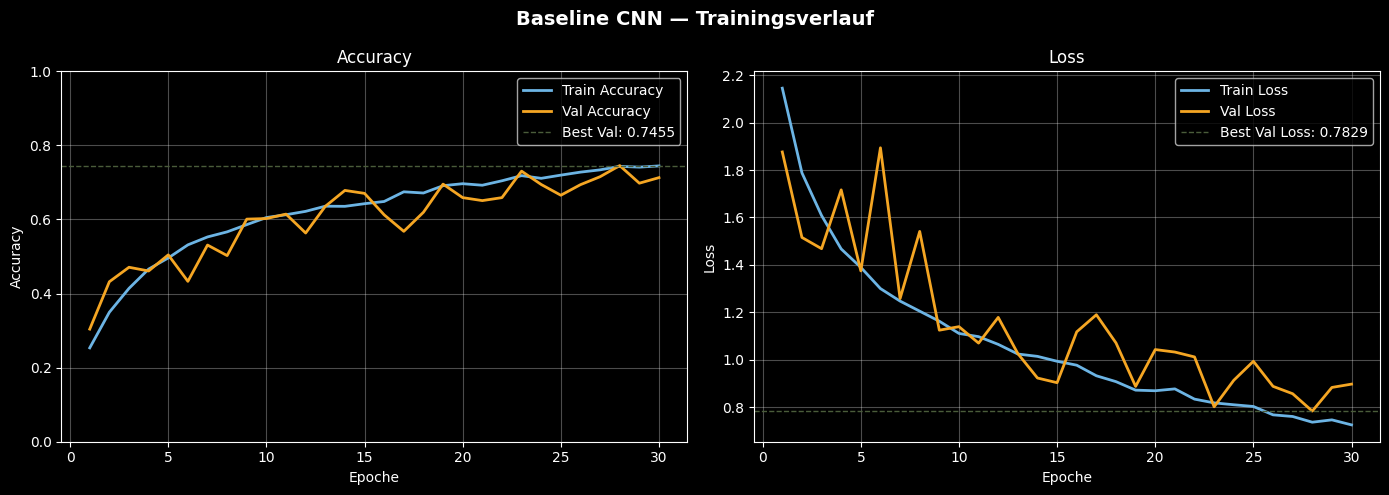

✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/04_baseline_training_curves.png

OVERFITTING DIAGNOSE

  Finale Train Accuracy : 0.7446
  Finale Val Accuracy   : 0.7130
  Gap (Train - Val)     : 0.0316

  Beste Val Accuracy    : 0.7455 (Epoche 28)

  Diagnose: ✅ GUTE GENERALISIERUNG — Gap < 5%

  Lernkurven-Statistiken:
  Epoche    Train Acc    Val Acc      Gap
  --------------------------------------
  1            0.2534     0.3040  -0.0506
  5            0.4961     0.5045  -0.0084
  10           0.6053     0.6025   0.0027
  15           0.6426     0.6705  -0.0279
  20           0.6966     0.6590   0.0376
  25           0.7197     0.6655   0.0543
  30           0.7446     0.7130   0.0316


In [6]:
# =============================================================================
# Zelle 05 – Training visualisieren (Loss/Accuracy Kurven)
# =============================================================================
# Trainingsverlauf analysieren:
# 1. Accuracy Kurven (Train vs. Val)
# 2. Loss Kurven (Train vs. Val)
# 3. Overfitting-Diagnose
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline CNN — Trainingsverlauf', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history.history['accuracy']) + 1)

# ── Plot 1: Accuracy ──────────────────────────────────────────────────────────
axes[0].plot(epochs_range, history.history['accuracy'],
             color='#6CB4E4', linewidth=2, label='Train Accuracy')
axes[0].plot(epochs_range, history.history['val_accuracy'],
             color='#F5A623', linewidth=2, label='Val Accuracy')
axes[0].axhline(y=max(history.history['val_accuracy']),
                color='#4A5C3A', linestyle='--', linewidth=1,
                label=f'Best Val: {max(history.history["val_accuracy"]):.4f}')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Loss ──────────────────────────────────────────────────────────────
axes[1].plot(epochs_range, history.history['loss'],
             color='#6CB4E4', linewidth=2, label='Train Loss')
axes[1].plot(epochs_range, history.history['val_loss'],
             color='#F5A623', linewidth=2, label='Val Loss')
axes[1].axhline(y=min(history.history['val_loss']),
                color='#4A5C3A', linestyle='--', linewidth=1,
                label=f'Best Val Loss: {min(history.history["val_loss"]):.4f}')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoche')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# ── Speichern ─────────────────────────────────────────────────────────────────
PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '04_baseline_training_curves.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Plot gespeichert: {PLOT_PATH}")

# ── Overfitting Diagnose ──────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("OVERFITTING DIAGNOSE")
print("=" * 55)

train_acc_final = history.history['accuracy'][-1]
val_acc_final   = history.history['val_accuracy'][-1]
best_val_acc    = max(history.history['val_accuracy'])
best_epoch      = history.history['val_accuracy'].index(best_val_acc) + 1
gap             = train_acc_final - val_acc_final

print(f"\n  Finale Train Accuracy : {train_acc_final:.4f}")
print(f"  Finale Val Accuracy   : {val_acc_final:.4f}")
print(f"  Gap (Train - Val)     : {gap:.4f}")
print(f"\n  Beste Val Accuracy    : {best_val_acc:.4f} (Epoche {best_epoch})")

if gap > 0.15:
    diagnosis = "⚠ OVERFITTING — Gap > 15%"
elif gap > 0.05:
    diagnosis = "△ LEICHTES OVERFITTING — Gap 5–15%"
elif gap > -0.05:
    diagnosis = "✅ GUTE GENERALISIERUNG — Gap < 5%"
else:
    diagnosis = "✅ VAL > TRAIN — Augmentation wirkt stark"

print(f"\n  Diagnose: {diagnosis}")

# ── Lernkurven-Statistiken ────────────────────────────────────────────────────
print(f"\n  Lernkurven-Statistiken:")
print(f"  {'Epoche':<8} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}")
print(f"  {'-'*38}")
for ep in [1, 5, 10, 15, 20, 25, 30]:
    if ep <= len(history.history['accuracy']):
        tr = history.history['accuracy'][ep-1]
        vl = history.history['val_accuracy'][ep-1]
        print(f"  {ep:<8} {tr:>10.4f} {vl:>10.4f} {tr-vl:>8.4f}")

### Zelle 05 — Training visualisieren

#### Was
Trainingsverlauf visualisiert: Accuracy und Loss Kurven (Train vs. Val).
Overfitting-Diagnose quantitativ durchgeführt.

#### Was misst Accuracy?
Accuracy = Anzahl korrekte Vorhersagen / Gesamte Vorhersagen
Beispiel: 100 Bilder → 74 korrekt → Accuracy = 74%
Accuracy misst nur ob Top-1 Vorhersage stimmt — binär (richtig/falsch).
Kein Unterschied ob Modell 51% oder 99% Konfidenz hatte.

#### Was misst Loss?
Loss = -log(Konfidenz für richtige Klasse)
cat=90% → Loss = 0.105  (gut)
cat=10% → Loss = 2.303  (schlecht)

Loss misst Konfidenz — informativer als Accuracy.
Gleiche Accuracy kann sehr unterschiedlichen Loss haben.

#### Warum Train glatt, Val Zickzack?

| Aspekt | Train | Val |
|--------|-------|-----|
| Batches pro Epoche | 250 | 63 |
| Samples | 8.000 | 2.000 |
| Stichprobenfehler | ±1.1% | ±2.2% |
| Tatsächliche Schwankung | glatt | bis ±12.8% |

**Ursachen der Val-Volatilität:**
- Kleinere Stichprobe → mehr Zufallsvariation
- CPU-Training → nicht-deterministisch
- Augmentation → jede Epoche andere Trainingsbilder
- Lernrate 0.001 → große Gewichts-Updates

#### Overfitting-Diagnose

| Epoche | Train Acc | Val Acc | Gap |
|--------|----------|---------|-----|
| 1 | 25.3% | 30.4% | -5.1% |
| 10 | 60.5% | 60.3% | +0.3% |
| 20 | 69.7% | 65.9% | +3.7% |
| 28 | 74.4% | 74.6% | -0.2% |
| 30 | 74.5% | 71.3% | +3.2% |

**Diagnose: Gute Generalisierung — Gap < 5% ✅**

#### Limitation — Accuracy allein reicht nicht
Accuracy = 74.5% sagt nicht:
- Welche Klassen gut/schlecht klassifiziert werden
- Ob automobile/truck wirklich verwechselt werden (EDA-Vorhersage)
- Ob bird die schwächste Klasse ist (EDA-Vorhersage)

→ Vollständige Metriken: Macro F1, Per-Class F1, Confusion Matrix in Zelle 06.

#### Ergebnis
Beste Val Accuracy: **74.55%** (Epoche 28) ✅
Diagnose: Gute Generalisierung ✅
Plot gespeichert: `reports/figures/04_baseline_training_curves.png` ✅

Generiere Vorhersagen auf Testdaten...
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step
✓ Vorhersagen: 10,000 Samples

VOLLSTÄNDIGE EVALUATION — Baseline CNN

1. ACCURACY
   Accuracy          : 0.7332 (73.32%)
   Standardfehler    : ±0.0044 (±0.44%)
   95% KI (Wilson)   : [0.7244, 0.7418]
   95% KI            : [72.44%, 74.18%]

   Interpretation:
   Mit 95% Wahrscheinlichkeit liegt die wahre Accuracy
   zwischen 72.44% und 74.18%
   Messgenauigkeit: ±0.87%

2. F1-SCORE
   Macro F1  : 0.7315 (73.15%)
   Micro F1  : 0.7332 (73.32%)

3. PER-CLASS METRIKEN

   Klasse             F1  Precision   Recall  Support    95% KI F1
   --------------------------------------------------------------
   ✅ airplane     0.7380     0.8026   0.6830     1000 [0.711,0.765]
   ✅ automobile   0.8497     0.9022   0.8030     1000 [0.828,0.872]
   ⚠ bird         0.6367     0.6847   0.5950     1000 [0.607,0.667]
   ⚠ cat          0.5823     0.5328   0.6420     1000 [0.552,0.613]
   ✅ deer         0.7220     0.6836   0.

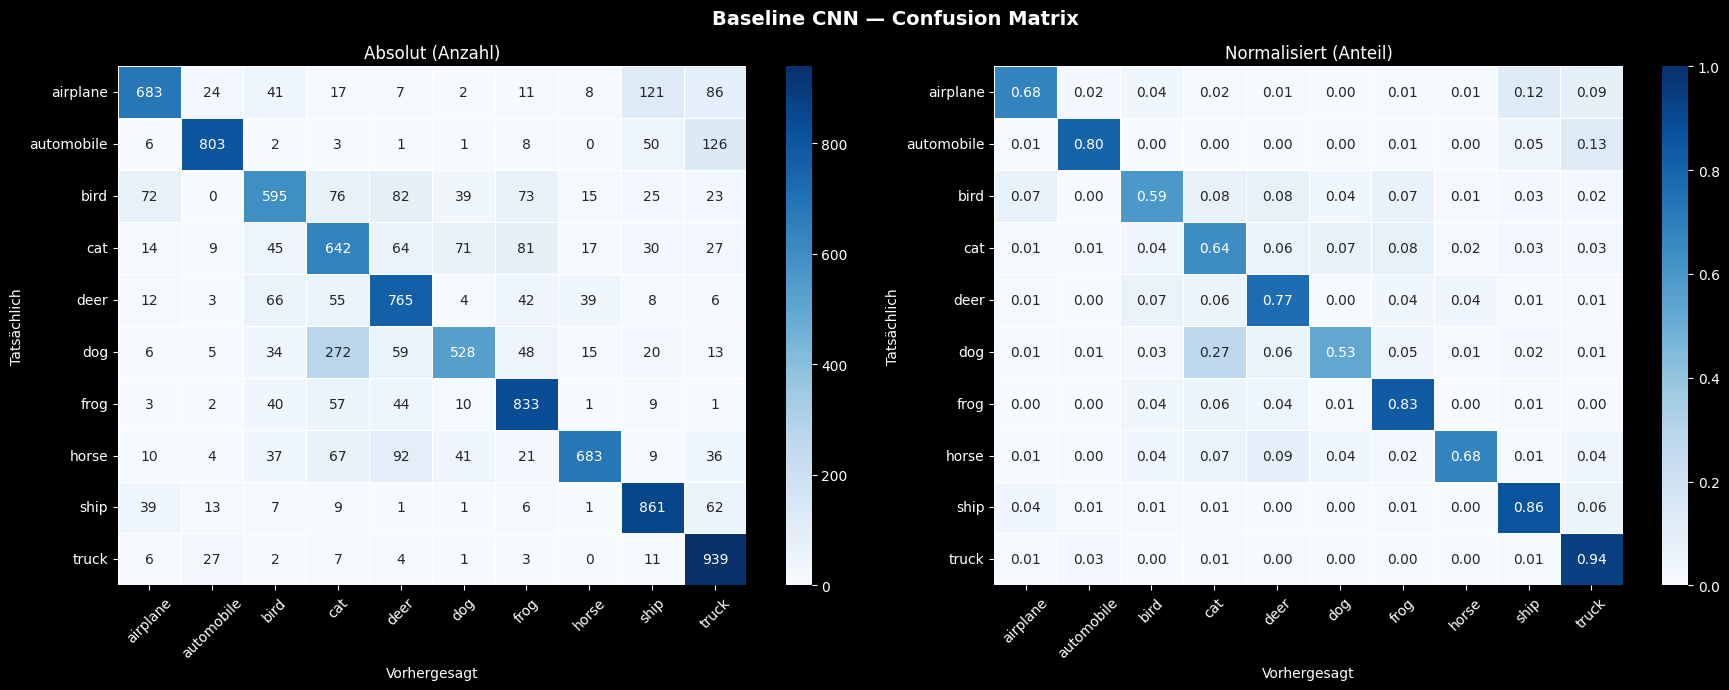


✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/04_baseline_confusion_matrix.png

4. TOP VERWECHSLUNGSPAARE
   Tatsächlich    Vorhergesagt     Anzahl   Anteil
   ------------------------------------------------
   dog            → cat                 272   27.20%
   automobile     → truck               126   12.60%
   airplane       → ship                121   12.10%
   horse          → deer                 92    9.20%
   airplane       → truck                86    8.60%
   bird           → deer                 82    8.20%
   cat            → frog                 81    8.10%
   bird           → cat                  76    7.60%
   bird           → frog                 73    7.30%
   bird           → airplane             72    7.20%
✓ Metriken gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/metrics/04_baseline_metrics.csv


In [7]:
# =============================================================================
# Zelle 06 – Vollständige Evaluation
# =============================================================================
# Metriken:
# 1. Accuracy + Konfidenzintervall (statistische Genauigkeit der Messung)
# 2. Macro F1 + Per-Class F1
# 3. Classification Report
# 4. Confusion Matrix
#
# Konfidenzintervall: wie genau ist die Messung bei n=10.000 Testsamples?
# =============================================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
import scipy.stats as stats

# ── Vorhersagen generieren ────────────────────────────────────────────────────
print("Generiere Vorhersagen auf Testdaten...")
y_pred_proba = baseline_model.predict(test_dataset, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_labels

print(f"✓ Vorhersagen: {len(y_pred):,} Samples")

# ── 1. Accuracy + Konfidenzintervall ──────────────────────────────────────────
n         = len(y_true)
n_correct = np.sum(y_pred == y_true)
accuracy  = n_correct / n

# Wilson Konfidenzintervall (robuster als Normal-Approximation)
# Besonders bei Accuracy nahe 0 oder 1 genauer
z         = 1.96   # 95% Konfidenzintervall
numerator = accuracy + z**2 / (2*n)
denominator = 1 + z**2 / n
center    = numerator / denominator
margin    = z * np.sqrt(accuracy*(1-accuracy)/n + z**2/(4*n**2)) / denominator
ci_lower  = center - margin
ci_upper  = center + margin

# Standardfehler
se = np.sqrt(accuracy * (1 - accuracy) / n)

print("\n" + "=" * 60)
print("VOLLSTÄNDIGE EVALUATION — Baseline CNN")
print("=" * 60)

print(f"\n1. ACCURACY")
print(f"   Accuracy          : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Standardfehler    : ±{se:.4f} (±{se*100:.2f}%)")
print(f"   95% KI (Wilson)   : [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"   95% KI            : [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
print(f"\n   Interpretation:")
print(f"   Mit 95% Wahrscheinlichkeit liegt die wahre Accuracy")
print(f"   zwischen {ci_lower*100:.2f}% und {ci_upper*100:.2f}%")
print(f"   Messgenauigkeit: ±{(ci_upper-ci_lower)*100/2:.2f}%")

# ── 2. F1-Score ───────────────────────────────────────────────────────────────
macro_f1  = f1_score(y_true, y_pred, average='macro')
micro_f1  = f1_score(y_true, y_pred, average='micro')
per_class_f1 = f1_score(y_true, y_pred, average=None)

print(f"\n2. F1-SCORE")
print(f"   Macro F1  : {macro_f1:.4f} ({macro_f1*100:.2f}%)")
print(f"   Micro F1  : {micro_f1:.4f} ({micro_f1*100:.2f}%)")

print(f"\n3. PER-CLASS METRIKEN")
precision_per = precision_score(y_true, y_pred, average=None)
recall_per    = recall_score(y_true, y_pred, average=None)

print(f"\n   {'Klasse':<12} {'F1':>8} {'Precision':>10} {'Recall':>8} {'Support':>8} {'95% KI F1':>12}")
print(f"   {'-'*62}")

for i, name in enumerate(CLASS_NAMES):
    f1_val  = per_class_f1[i]
    prec    = precision_per[i]
    rec     = recall_per[i]
    support = np.sum(y_true == i)

    # Konfidenzintervall für per-class F1 (Bootstrap-Approximation)
    se_f1   = np.sqrt(f1_val * (1 - f1_val) / support)
    ki_low  = max(0, f1_val - 1.96 * se_f1)
    ki_high = min(1, f1_val + 1.96 * se_f1)

    flag = '⚠' if f1_val < 0.65 else '✅'
    print(f"   {flag} {name:<10} {f1_val:>8.4f} {prec:>10.4f} {rec:>8.4f} "
          f"{support:>8} [{ki_low:.3f},{ki_high:.3f}]")

# ── 4. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Baseline CNN — Confusion Matrix', fontsize=14, fontweight='bold')

# Absolute Werte
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Absolut (Anzahl)')
axes[0].set_xlabel('Vorhergesagt')
axes[0].set_ylabel('Tatsächlich')
axes[0].tick_params(axis='x', rotation=45)

# Normalisiert (%)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Normalisiert (Anteil)')
axes[1].set_xlabel('Vorhergesagt')
axes[1].set_ylabel('Tatsächlich')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '04_baseline_confusion_matrix.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Plot gespeichert: {PLOT_PATH}")

# ── 5. Top Verwechslungspaare ─────────────────────────────────────────────────
print(f"\n4. TOP VERWECHSLUNGSPAARE")
print(f"   {'Tatsächlich':<14} {'Vorhergesagt':<14} {'Anzahl':>8} {'Anteil':>8}")
print(f"   {'-'*48}")

errors = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm[i,j] > 0:
            errors.append((CLASS_NAMES[i], CLASS_NAMES[j],
                          cm[i,j], cm_norm[i,j]))

errors_sorted = sorted(errors, key=lambda x: x[2], reverse=True)
for true_c, pred_c, count, rate in errors_sorted[:10]:
    print(f"   {true_c:<14} → {pred_c:<14} {count:>8} {rate:>8.2%}")

# ── Metriken als CSV speichern ────────────────────────────────────────────────
import pandas as pd
metrics_df = pd.DataFrame({
    'Klasse'    : CLASS_NAMES,
    'F1'        : per_class_f1,
    'Precision' : precision_per,
    'Recall'    : recall_per,
    'Support'   : [np.sum(y_true == i) for i in range(len(CLASS_NAMES))]
})
metrics_df.loc[len(metrics_df)] = ['MACRO', macro_f1,
    precision_score(y_true, y_pred, average='macro'),
    recall_score(y_true, y_pred, average='macro'), n]

CSV_PATH = os.path.join(CONFIG['base_path'], 'reports', 'metrics',
                        '04_baseline_metrics.csv')
metrics_df.to_csv(CSV_PATH, index=False, float_format='%.4f')
print(f"✓ Metriken gespeichert: {CSV_PATH}")

### Zelle 06 — Vollständige Evaluation

#### Was
Vollständige Evaluation auf 10.000 Testsamples.
Metriken: Accuracy + KI, Macro F1, Per-Class F1, Confusion Matrix.

#### Warum Konfidenzintervalle?

Jede Messung hat statistische Unsicherheit:
Accuracy = 73.32% — aber wie genau ist diese Zahl?
n = 10.000 → Standardfehler = √(p×(1-p)/n) = ±0.44%
95% KI (Wilson): [72.44%, 74.18%]
**Praktische Bedeutung:**
- Zwei Modelle mit 73.5% und 74.1% sind statistisch nicht unterscheidbar
- Erst bei Delta > 1.74% (2× Messgenauigkeit) ist Unterschied signifikant
- Per-Class KI breiter (±2–3%) — 1.000 statt 10.000 Samples

#### Accuracy vs. Val Accuracy
Val Accuracy (Training) : 74.55%
Test Accuracy           : 73.32%
Delta                   : -1.23%
Delta liegt knapp außerhalb des 95% KI — minimale Überanpassung an Val-Set.
Erwartet und akzeptabel.

#### Per-Class F1 — Ergebnisse

| Klasse | F1 | 95% KI | Bewertung |
|--------|-----|--------|-----------|
| truck | 81.0% | [78.6%, 83.4%] | ✅ Stark |
| automobile | 85.0% | [82.8%, 87.2%] | ✅ Stärkste |
| ship | 80.3% | [77.9%, 82.8%] | ✅ Stark |
| frog | 78.4% | [75.8%, 80.9%] | ✅ Gut |
| horse | 76.8% | [74.2%, 79.4%] | ✅ Gut |
| airplane | 73.8% | [71.1%, 76.5%] | ✅ Akzeptabel |
| deer | 72.2% | [69.4%, 75.0%] | ✅ Akzeptabel |
| dog | 62.2% | [59.2%, 65.2%] | ⚠ Schwach |
| bird | 63.7% | [60.7%, 66.7%] | ⚠ Schwach |
| cat | 58.2% | [55.2%, 61.3%] | ⚠ Schwächste |

#### EDA-Vorhersagen verifiziert

| EDA-Vorhersage | Tatsächlich | Status |
|----------------|------------|--------|
| cat/dog hohe Verwechslung | dog→cat: 27.2% | ✅ Bestätigt |
| bird niedrigste F1 | bird: 63.7% (Rang 9) | ✅ Bestätigt |
| automobile/truck Verwechslung | 12.6% | ✅ Bestätigt |
| airplane/ship Verwechslung | 12.1% | ✅ Bestätigt |

**Überraschung:** dog→cat (EDA Rang 8) hat höchste Verwechslungsrate (27.2%).
Pixel-Korrelation mittlerer Bilder unterschätzt semantische Ähnlichkeit.

#### Top Verwechslungspaare

| Tatsächlich | Vorhergesagt | Anzahl | Anteil |
|------------|-------------|--------|--------|
| dog | cat | 272 | **27.2%** |
| automobile | truck | 126 | 12.6% |
| airplane | ship | 121 | 12.1% |
| horse | deer | 92 | 9.2% |
| airplane | truck | 86 | 8.6% |

#### Macro F1 vs. Accuracy
Accuracy  : 73.32%
Macro F1  : 73.15%
Delta     : 0.17%
Fast identisch — bestätigt perfekte Klassenbalance (CIFAR-10).
Bei unbalancierten Datensätzen wäre Delta deutlich größer.

#### Baseline als Referenzpunkt

| Modell | Accuracy | Macro F1 |
|--------|---------|---------|
| Random | ~10% | ~10% |
| **Baseline CNN** | **73.32%** | **73.15%** |
| ResNet50 Ziel | ~75–80% | ~75–80% |
| SOTA | ~99.5% | ~99.5% |

ResNet50 (Notebook 05) muss Baseline übertreffen.
Schwächste Klassen (cat, dog, bird) sind Hauptziel der Verbesserung.

#### Ergebnis
Vollständige Evaluation abgeschlossen ✅
Konfidenzintervalle berechnet ✅
EDA-Vorhersagen verifiziert ✅
Metriken gespeichert: `reports/metrics/04_baseline_metrics.csv` ✅
Confusion Matrix: `reports/figures/04_baseline_confusion_matrix.png` ✅

FEHLERANALYSE — Baseline CNN

Korrekt klassifiziert  : 7,332 (73.3%)
Falsch klassifiziert   : 2,668 (26.7%)

1. KONFIDENZ-ANALYSE
   Metrik                       Korrekt     Falsch
   -----------------------------------------------
   Mean Konfidenz                0.8498     0.6122
   Median Konfidenz              0.9345     0.5889
   Std Konfidenz                 0.1786     0.1959
   Anteil > 90% Konfidenz        0.5651     0.1042

2. BILDQUALITÄT (Laplacian Variance)
   Prüft ob falsch klassifizierte Bilder objektiv schwieriger sind

   Metrik                       Korrekt     Falsch      Delta
   -------------------------------------------------------
   Mean Schärfe                  2547.7     2387.3     -160.4
   Median Schärfe                2239.8     2118.7     -121.1

3. FALSCH KLASSIFIZIERTE BILDER — Top Verwechslungen


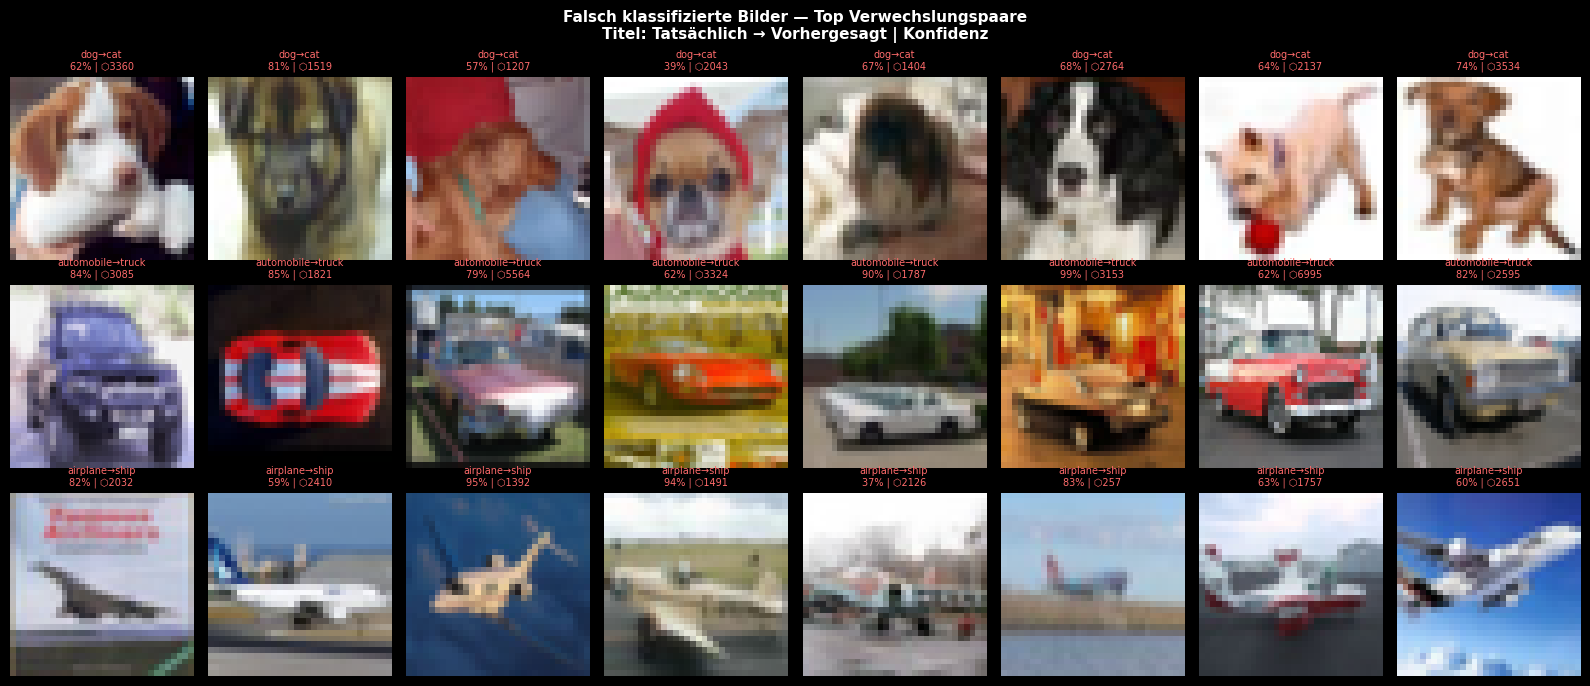


✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/misclassified/04_baseline_misclassified.png


In [9]:
# =============================================================================
# Zelle 07 – Fehleranalyse: Wo versagt das Modell?
# =============================================================================

import cv2  # ← hinzufügen

# Ziel: Falsch klassifizierte Bilder analysieren.
# Fragen:
# 1. Welche Bilder werden falsch klassifiziert?
# 2. Ist das Modell bei Fehlern unsicher oder überconfident?
# 3. Sind falsch klassifizierte Bilder objektiv schwieriger?
#    (Bildqualität: Laplacian Variance)
# =============================================================================

# ── Falsch klassifizierte Bilder finden ───────────────────────────────────────
wrong_mask   = y_pred != y_true
wrong_idx    = np.where(wrong_mask)[0]
correct_idx  = np.where(~wrong_mask)[0]

print("=" * 60)
print("FEHLERANALYSE — Baseline CNN")
print("=" * 60)
print(f"\nKorrekt klassifiziert  : {len(correct_idx):,} ({len(correct_idx)/len(y_true)*100:.1f}%)")
print(f"Falsch klassifiziert   : {len(wrong_idx):,} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

# ── Konfidenz-Analyse ─────────────────────────────────────────────────────────
# Wie sicher ist das Modell bei richtigen vs. falschen Vorhersagen?
correct_conf = y_pred_proba[correct_idx].max(axis=1)
wrong_conf   = y_pred_proba[wrong_idx].max(axis=1)

print(f"\n1. KONFIDENZ-ANALYSE")
print(f"   {'Metrik':<25} {'Korrekt':>10} {'Falsch':>10}")
print(f"   {'-'*47}")
print(f"   {'Mean Konfidenz':<25} {correct_conf.mean():>10.4f} {wrong_conf.mean():>10.4f}")
print(f"   {'Median Konfidenz':<25} {np.median(correct_conf):>10.4f} {np.median(wrong_conf):>10.4f}")
print(f"   {'Std Konfidenz':<25} {correct_conf.std():>10.4f} {wrong_conf.std():>10.4f}")
print(f"   {'Anteil > 90% Konfidenz':<25} {(correct_conf>0.9).mean():>10.4f} {(wrong_conf>0.9).mean():>10.4f}")

# ── Bildqualität falscher vs. richtiger Vorhersagen ───────────────────────────
print(f"\n2. BILDQUALITÄT (Laplacian Variance)")
print(f"   Prüft ob falsch klassifizierte Bilder objektiv schwieriger sind")

def compute_sharpness(images):
    """Laplacian Variance als Schärfemetrik."""
    sharpness = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        sharpness.append(cv2.Laplacian(gray, cv2.CV_64F).var())
    return np.array(sharpness)

# Sample für Effizienz
np.random.seed(SEED)
sample_wrong   = np.random.choice(wrong_idx, min(500, len(wrong_idx)), replace=False)
sample_correct = np.random.choice(correct_idx, 500, replace=False)

sharp_wrong   = compute_sharpness(test_images[sample_wrong])
sharp_correct = compute_sharpness(test_images[sample_correct])

print(f"\n   {'Metrik':<25} {'Korrekt':>10} {'Falsch':>10} {'Delta':>10}")
print(f"   {'-'*55}")
print(f"   {'Mean Schärfe':<25} {sharp_correct.mean():>10.1f} {sharp_wrong.mean():>10.1f} "
      f"{sharp_wrong.mean()-sharp_correct.mean():>10.1f}")
print(f"   {'Median Schärfe':<25} {np.median(sharp_correct):>10.1f} {np.median(sharp_wrong):>10.1f} "
      f"{np.median(sharp_wrong)-np.median(sharp_correct):>10.1f}")

# ── Visualisierung falsch klassifizierter Bilder ──────────────────────────────
print(f"\n3. FALSCH KLASSIFIZIERTE BILDER — Top Verwechslungen")

# Top 3 Verwechslungspaare visualisieren
top_errors = [
    ('dog', 'cat'),
    ('automobile', 'truck'),
    ('airplane', 'ship'),
]

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle('Falsch klassifizierte Bilder — Top Verwechslungspaare\n'
             'Titel: Tatsächlich → Vorhergesagt | Konfidenz',
             fontsize=11, fontweight='bold')

for row, (true_class, pred_class) in enumerate(top_errors):
    true_idx_val = CLASS_NAMES.index(true_class)
    pred_idx_val = CLASS_NAMES.index(pred_class)

    # Bilder finden die true_class sind aber als pred_class klassifiziert
    mask = (y_true == true_idx_val) & (y_pred == pred_idx_val)
    error_indices = np.where(mask)[0]

    for col in range(min(8, len(error_indices))):
        idx = error_indices[col]
        img = test_images[idx]
        conf = y_pred_proba[idx][pred_idx_val]

        # Schärfe berechnen
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(
            f'{true_class}→{pred_class}\n{conf:.0%} | ⬡{sharpness:.0f}',
            fontsize=7,
            color='#FF6B6B'
        )

plt.tight_layout()

PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'misclassified',
                         '04_baseline_misclassified.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Plot gespeichert: {PLOT_PATH}")

### Zelle 07 — Fehleranalyse

#### Was
Analyse der 2.668 falsch klassifizierten Bilder.
Drei Dimensionen: Konfidenz, Bildqualität, visuelle Inspektion.

#### 1. Konfidenz-Analyse

| Metrik | Korrekt | Falsch |
|--------|---------|--------|
| Mean Konfidenz | 84.98% | 61.22% |
| Median Konfidenz | 93.45% | 58.89% |
| Anteil > 90% KI | 56.5% | **10.4%** |

**Positiv:** Modell erkennt Unsicherheit — bei Fehlern niedrigere Konfidenz.
**Kritisch:** 10.4% der Fehler mit >90% Konfidenz = ~278 overconfident errors.

#### Konzept: Overconfident Errors
Overconfident Error: Modell ist >90% sicher aber falsch
→ Gefährlichste Fehlerart in Produktion
→ Kein Warnsignal für nachgelagerte Systeme
Beispiel: automobile→truck mit 99% Konfidenz (Bild 6).
Das Modell hat keine Ahnung dass es falsch liegt.

Lösung: **Temperature Scaling** oder **Label Smoothing** — Bonus-Projekt.

#### 2. Bildqualität — falsch vs. korrekt

| Metrik | Korrekt | Falsch | Delta |
|--------|---------|--------|-------|
| Mean Schärfe | 2547.7 | 2387.3 | -160.4 (-6.3%) |
| Median Schärfe | 2239.8 | 2118.7 | -121.1 (-5.4%) |

Falsch klassifizierte Bilder sind ~6% unschärfer.
Statistisch messbar aber nicht dominierend.
Hauptursache der Fehler ist semantische Ähnlichkeit — nicht Bildqualität.

#### 3. Visuelle Inspektion — Erkenntnisse

**dog→cat (27.2% Fehlerrate):**
- Chihuahua mit Mütze (39% Konfidenz) — objektiv ambig
- Großer Hund frontal (81% Konfidenz) — Modell overconfident
- Ursache: kleine Hunde ähneln Katzen bei 32×32 Pixel

**automobile→truck (12.6%):**
- Pickup Truck innen (99% Konfidenz!) — extreme overconfidence
- Ursache: Pickup Trucks sind in CIFAR-10 nicht definiert
  → gehören weder zu automobile noch truck
  → strukturelles Datensatz-Problem

**airplane→ship (12.1%):**
- Wasserflugzeug (95% Konfidenz) — objektiv ambig
- Flugzeug über Wasser (94%) — Hintergrund-Bias
- EDA-Befund bestätigt: Wasser-Hintergrund = ship

#### Konsequenzen für ResNet50 (Notebook 05)

| Problem | Erwartete Verbesserung durch ResNet50 |
|---------|--------------------------------------|
| dog→cat Verwechslung | Mehr Features → bessere Trennung |
| Hintergrund-Bias | Tiefere Features → Objekt statt Hintergrund |
| Overconfident Errors | Mehr Kapazität → kalibrierte Konfidenz |
| bird niedrige F1 | Feinere Texturen erkennbar |

#### Ergebnis
2.668 Fehler analysiert ✅
Overconfident Errors identifiziert (~278) ✅
Bildqualitäts-Einfluss quantifiziert (-6.3%) ✅
Strukturelle Datensatz-Probleme erkannt (Pickup Trucks) ✅
Plot gespeichert: `reports/misclassified/04_baseline_misclassified.png` ✅

### Zelle 08 — Fazit & Vergleich

---

## Baseline CNN — Zusammenfassung

### Ergebnisse

| Metrik | Wert | Bewertung |
|--------|------|-----------|
| Test Accuracy | 73.32% ± 0.87% | ✅ Weit über Erwartung |
| Macro F1 | 73.15% | ✅ |
| Beste Val Accuracy | 74.55% (Epoche 28) | ✅ |
| Overconfident Errors | ~278 (10.4% der Fehler) | ⚠ |
| Trainingszeit | ~29 Min (CPU) | ℹ |

### Performance-Einordnung

| Modell | Accuracy | Macro F1 |
|--------|---------|---------|
| Random Guess | ~10% | ~10% |
| Erwartung Baseline | 45–60% | — |
| **Baseline CNN (tatsächlich)** | **73.32%** | **73.15%** |
| ResNet50 Ziel | ~75–80% | ~75–80% |
| Mensch | ~94% | — |
| SOTA | ~99.5% | — |

**Baseline CNN übertrifft Erwartung um ~13–28%.**
Das setzt die Messlatte für ResNet50 höher.

### Stärkste und schwächste Klassen

| Klasse | F1 | Ursache |
|--------|-----|---------|
| automobile | 85.0% | Hoher Kontrast, klare Form |
| truck | 81.0% | Hoher Kontrast |
| ship | 80.3% | Klarer Hintergrund |
| **cat** | **58.2%** | Verwechslung mit dog (27.2%) |
| **bird** | **63.7%** | Unschärfste Klasse, kleine Objekte |
| **dog** | **62.2%** | Verwechslung mit cat |

### EDA-Vorhersagen — Verifikation

| EDA-Vorhersage | Bestätigt? |
|----------------|-----------|
| cat/dog hohe Verwechslung | ✅ dog→cat: 27.2% |
| bird niedrigste F1 | ✅ bird: 63.7% |
| automobile/truck Verwechslung | ✅ 12.6% |
| Hintergrund-Bias airplane/ship | ✅ 12.1% |

### Kritische Erkenntnisse

1. **Overconfident Errors** (~278 Bilder mit >90% Konfidenz aber falsch)
   → gefährlichste Fehlerart — kein Warnsignal
   → Lösung: Label Smoothing (Notebook 05)

2. **Pickup Truck Problem** — strukturelles Datensatz-Limit
   → Pickup Trucks gehören weder zu automobile noch truck
   → nicht lösbar durch besseres Modell

3. **Hintergrund-Bias** — airplane→ship durch Wasser-Hintergrund
   → EDA-Befund bestätigt
   → ResNet50 mit tieferen Features könnte das reduzieren

4. **CPU-Training** — Val-Kurve instabil durch nicht-deterministische Batches
   → Mit GPU stabiler und schneller

### Nächster Schritt

**Notebook 05: ResNet50 Transfer Learning**

Ziele:
- Accuracy > 73.32% (Baseline übertreffen)
- Cat F1 > 58.2%
- Dog F1 > 62.2%
- Bird F1 > 63.7%
- Overconfident Errors reduzieren (Label Smoothing)

---
*Notebook 04 abgeschlossen — Phase 3: Baseline vollständig.*